In [1]:
import numpy as np
import ase
import pyscf
import equiv_dens.utils.base as utils

Use "numpy" for Fourier Transform


In [2]:
#np_path = 'datasets/alanine_dipeptide_rotated.npy'
#density_path = 'datasets/alanine_dipeptide_rotated_mo_calc.npy'
np_path = 'datasets/alanine_dipeptide_dft_small.npy'
density_path = 'datasets/alanine_dipeptide_dft_small_mo_calc.npy'

In [3]:
import equiv_dens.utils.base as utils
import ase.io
al = np.load(np_path, allow_pickle=True).item()
al_mo = np.load(density_path, allow_pickle=True)

mols = utils.npy_to_ase(al['positions'], al['atom_types'])

ase.io.write('datasets/alanine_dipeptide_small.xyz', mols)


In [4]:
from equiv_dens.data.density_dataset import AtomsDensityData
from functools import partial
from equiv_dens.utils.grids import cubical_grid, cubical_sampling, CubicalGrid
import torch

cube_grid_fn = partial(cubical_grid, nx=50, ny=50, nz=50,
                       extent=np.array([20, 20, 20]),
                       origin=np.array([5, 5 , 5]))
cube_sampling_fn = cubical_sampling

dataset = AtomsDensityData(np_path=np_path, density_path=density_path,
                                      orbitals_path='datasets/augccpvqzjkfit_orbital_basis_df.npy',
                                      density_n_samp=10000000000,
                                      required_properties=['density'],
                                      center_positions=False,
                                      radial_coeffs_file='datasets/augccpvqzjkfit_radial_coeffs_df.npy',
                                      dtype=torch.float,
                                      grid_fn=cube_grid_fn,
                                      sampling_fn=cube_sampling_fn)

Starting atomsdata density init
Some variables
atoms keys dict_keys(['atom_numbers', 'atom_types', 'positions', 'energy', 'forces'])
mol_dict [('C', array([13.52, 12.92, 11.91])), ('H', array([13.62, 12.67, 12.97])), ('H', array([13.56, 12.08, 11.22])), ('H', array([14.45, 13.44, 11.7 ])), ('C', array([12.18, 13.65, 11.83])), ('O', array([11.36, 13.14, 11.08])), ('N', array([12.18, 14.92, 12.22])), ('H', array([12.99, 15.21, 12.74])), ('C', array([11.43, 16.04, 11.68])), ('H', array([10.41, 15.76, 11.42])), ('C', array([11.5 , 17.18, 12.7 ])), ('H', array([11.18, 16.97, 13.72])), ('H', array([12.54, 17.49, 12.79])), ('H', array([10.95, 18.03, 12.3 ])), ('C', array([12.11, 16.3 , 10.35])), ('O', array([13.06, 17.09, 10.33])), ('N', array([11.86, 15.45,  9.35])), ('H', array([11.21, 14.75,  9.68])), ('C', array([12.46, 15.49,  8.04])), ('H', array([13.54, 15.35,  8.12])), ('H', array([12.16, 14.62,  7.45])), ('H', array([12.24, 16.38,  7.45]))]
finished init


In [5]:
#from pyscf.dft import numint
#from pyscf.lib import param#

#mol.build()
#print('atoms', mol.atom)
#grid_spec = cube_grid_fn(calc_npy)
#grid_coords, coord_weights = cube_sampling_fn(grid_spec, 100000000, calc_npy['atom_types'], calc_npy['positions'][[0]])
#print('grid_coords', grid_coords.shape)
#scaled_grid_coords = grid_coords / param.BOHR
#print('scaled grid_coords', scaled_grid_coords.shape)


#print('mol_dict', mol.pack())

In [6]:
#ao = numint.eval_ao(mol, scaled_grid_coords[0])
#print('ao shape', ao.shape)

#rho = numint.eval_rho2(mol, ao, **calc_dict)
#print('rho shape', rho.shape)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
preparing sample
density mol atoms [('C', array([13.91, 12.7 , 12.02])), ('H', array([14.7 , 12.56, 11.28])), ('H', array([14.22, 12.63, 13.06])), ('H', array([13.26, 11.84, 11.84])), ('C', array([13.18, 14.02, 11.8 ])), ('O', array([13.73, 15.08, 12.06])), ('N', array([11.93, 13.88, 11.34])), ('H', array([11.69, 12.91, 11.16])), ('C', array([10.93, 14.77, 10.79])), ('H', array([10.55, 14.31,  9.88])), ('C', array([ 9.81, 14.99, 11.81])), ('H', array([10.05, 15.51, 12.74])), ('H', array([ 9.11, 15.65, 11.3 ])), ('H', array([ 9.22, 14.13, 12.14])), ('C', array([11.49, 16.11, 10.36])), ('O', array([11.31, 17.13, 11.03])), ('N', array([12.25, 16.16,  9.26])), ('H', array([12.47, 15.3 ,  8.77])), ('C', array([13.16, 17.22,  8.88])), ('H', array([13.14, 18.08,  9.54])), ('H', array([14.14, 16.74,  8.93])), ('H', array([13.11, 17.62,  7.87]))]
positions [[[13.91 12.7  12.02]
  [14.7  12.56 11.28]
  [14.22

<IPython.core.display.Javascript object>


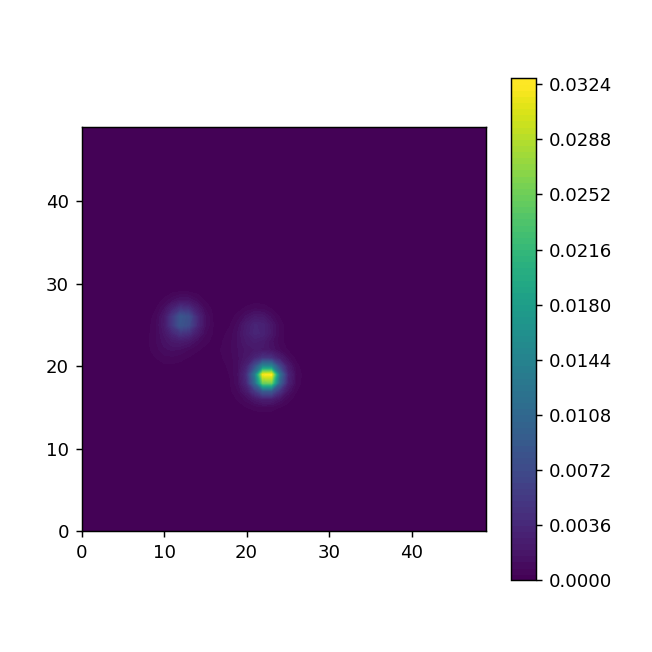

idx [    21   2521   5021 ... 119971 122471 124971]
pos tensor([[[13.9100, 12.7000, 12.0200],
         [14.7000, 12.5600, 11.2800],
         [14.2200, 12.6300, 13.0600],
         [13.2600, 11.8400, 11.8400],
         [13.1800, 14.0200, 11.8000],
         [13.7300, 15.0800, 12.0600],
         [11.9300, 13.8800, 11.3400],
         [11.6900, 12.9100, 11.1600],
         [10.9300, 14.7700, 10.7900],
         [10.5500, 14.3100,  9.8800],
         [ 9.8100, 14.9900, 11.8100],
         [10.0500, 15.5100, 12.7400],
         [ 9.1100, 15.6500, 11.3000],
         [ 9.2200, 14.1300, 12.1400],
         [11.4900, 16.1100, 10.3600],
         [11.3100, 17.1300, 11.0300],
         [12.2500, 16.1600,  9.2600],
         [12.4700, 15.3000,  8.7700],
         [13.1600, 17.2200,  8.8800],
         [13.1400, 18.0800,  9.5400],
         [14.1400, 16.7400,  8.9300],
         [13.1100, 17.6200,  7.8700]]])
dens shape (125000,)


In [17]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib notebook
%load_ext autoreload
%autoreload 2

sample = 20

print('preparing sample')
def2svp_sample = dataset.get_properties([sample])
print('loadded sample')
fig = plt.figure(figsize=(5, 5))


x, y  = np.meshgrid(np.arange(50), np.arange(50))
x_f = x.flatten()
y_f = y.flatten()
z_f = np.zeros_like(y_f) + 21
idx = np.ravel_multi_index((x_f, y_f, z_f), (50, 50, 50))
#X, Y, Z = np.meshgrid(np.arange(50) + 38, np.arange(50) + 38, np.arange(50) + 38)
#X = X.flatten()
#Y = Y.flatten()
#Z = Z.flatten()
#ndices = np.ravel_multi_index((X, Y, Z), (125, 125, 125))


ax1 = fig.add_subplot(111)
print('idx', idx)
dens = np.array(def2svp_sample['density'].squeeze())
print('pos', def2svp_sample['positions'])
print('dens shape', dens.shape)
dens2d_ccp = dens[idx]
dens2d_ccp = (dens2d_ccp.reshape(50, 50))
vmin = np.min(dens2d_ccp)
vmax = np.max(dens2d_ccp)
c1 = ax1.contourf(x, y, dens2d_ccp, vmin=vmin, vmax=vmax, levels=100)
ax1.set_aspect('equal')

fig.colorbar(c1, ax=ax1)
#plt.savefig('figures/target_vs_pred_dens.pdf', dpi=300)
plt.show()
                           